# Fraction Training for LightGBM on EMBER Dataset

This notebook implements the training of a LightGBM model on a fraction of the EMBER dataset. It includes data loading, feature extraction using `thrember`, model training, and evaluation.

In [7]:
import sys
import os

# Add local venv site-packages to path so thrember can be imported even if using external venv
# This assumes running from project root where venv/ exists
venv_site_packages = os.path.join(os.path.abspath(""), "venv", "Lib", "site-packages")
if os.path.exists(venv_site_packages):
    sys.path.append(venv_site_packages)

import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve
from thrember.features import PEFeatureExtractor

In [8]:
# Configuration
dataset_dir = r"Z:\ember2024_train_data"
X_path = os.path.join(dataset_dir, "X_train.dat")
y_path = os.path.join(dataset_dir, "y_train.dat")
plots_dir = os.path.join(dataset_dir, "plots_fraction_notebook")
os.makedirs(plots_dir, exist_ok=True)
chunk_size = 1000
limit_chunks = 3

if not os.path.exists(X_path) or not os.path.exists(y_path):
    print("Error: Vectorized data not found.")
    print("Please wait for the download and vectorization process to finish first!")
else:
    print(f"Data directory: {dataset_dir}")
    print(f"Will process {limit_chunks} chunks of {chunk_size} samples each.")

Data directory: Z:\ember2024_train_data
Will process 3 chunks of 1000 samples each.


In [9]:
# Load Data Metadata
extractor = PEFeatureExtractor()
ndim = extractor.dim

file_size = os.path.getsize(X_path)
nrows = file_size // (ndim * 4)

print(f"Total samples detected: {nrows}")
print(f"Feature dimensions: {ndim}")

# Open the files in memory-map mode (does NOT load into RAM)
X_memmap = np.memmap(X_path, dtype=np.float32, mode="r", shape=(nrows, ndim))
y_memmap = np.memmap(y_path, dtype=np.int32, mode="r", shape=(nrows,))

# Split data: 90% for training, 10% for validation/metrics
train_nrows = int(nrows * 0.9)
val_nrows = nrows - train_nrows
print(f"Training on {train_nrows} samples, Validating on {val_nrows} samples")

Total samples detected: 5252000
Feature dimensions: 2568
Training on 4726800 samples, Validating on 525200 samples


In [10]:
# Define LightGBM Parameters
params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 1024,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "verbose": -1
}

# Indices of categorical features in EMBER
categorical_features = [2, 3, 4, 5, 6, 701, 702]

In [11]:
# Train Loop
model = None

# Iterate over the training data in chunks to prevent RAM overload
chunks_processed = 0
for start_idx in range(0, train_nrows, chunk_size):
    if limit_chunks is not None and chunks_processed >= limit_chunks:
        print(f"Stopping early after {limit_chunks} chunks as requested.")
        break

    end_idx = min(start_idx + chunk_size, train_nrows)
    print(f"Training on chunk: {start_idx} to {end_idx}...")
    
    # Load ONLY this specific chunk into RAM
    X_chunk = np.array(X_memmap[start_idx:end_idx])
    y_chunk = np.array(y_memmap[start_idx:end_idx])
    
    # Filter out unlabeled data (where label is -1)
    valid_idx = y_chunk != -1
    X_chunk = X_chunk[valid_idx]
    y_chunk = y_chunk[valid_idx]
    
    if len(y_chunk) == 0:
        continue
        
    # Create LightGBM dataset for this chunk
    train_data = lgb.Dataset(
        X_chunk, 
        label=y_chunk, 
        categorical_feature=categorical_features,
        free_raw_data=False
    )
    
    # Train incrementally (online learning)
    model = lgb.train(
        params,
        train_data,
        num_boost_round=50, # Number of trees to add per chunk
        init_model=model,   # Pass the previous model to continue training
        keep_training_booster=True
    )

    chunks_processed += 1
    
print("\nTraining complete!")

Training on chunk: 0 to 1000...
Training on chunk: 1000 to 2000...
Training on chunk: 2000 to 3000...
Stopping early after 3 chunks as requested.

Training complete!


In [12]:
# ...existing code...
# Load Validation Data
print("Loading validation set...")

# LIMIT VALIDATION SIZE to avoid MemoryError
validation_limit = 50000 

# Calculate indices for validation
val_start = train_nrows
val_end = min(nrows, train_nrows + validation_limit)

print(f"Loading partial validation set from index {val_start} to {val_end}...")

X_val = np.array(X_memmap[val_start:val_end])
y_val = np.array(y_memmap[val_start:val_end])

# Filter out unlabeled data
valid_idx = y_val != -1
X_val = X_val[valid_idx]
y_val = y_val[valid_idx]
print(f"Validation set size: {X_val.shape[0]} samples")

Loading validation set...
Loading partial validation set from index 4726800 to 4776800...


Validation set size: 50000 samples


In [13]:
# Make Predictions
print("Making predictions on validation set...")
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)

Making predictions on validation set...


In [14]:
# Calculate Performance Metrics
auc = roc_auc_score(y_val, y_pred_prob)
acc = accuracy_score(y_val, y_pred)
print(f"Validation AUC: {auc:.4f}")
print(f"Validation Accuracy: {acc:.4f}")

Validation AUC: 0.6447
Validation Accuracy: 0.5917


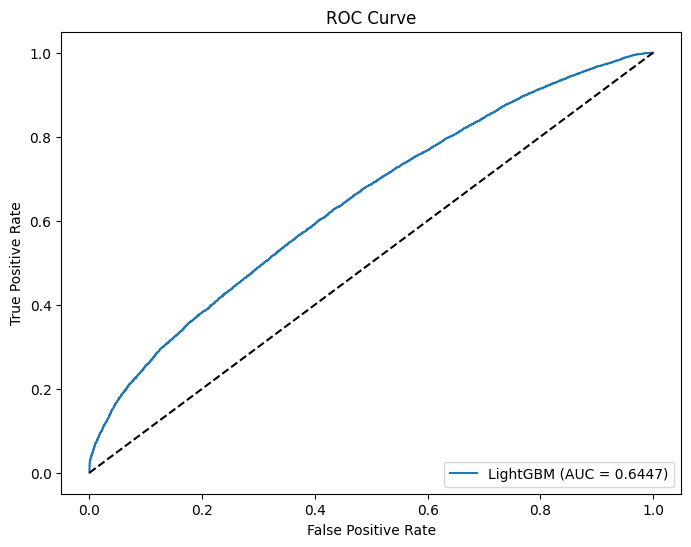

In [15]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

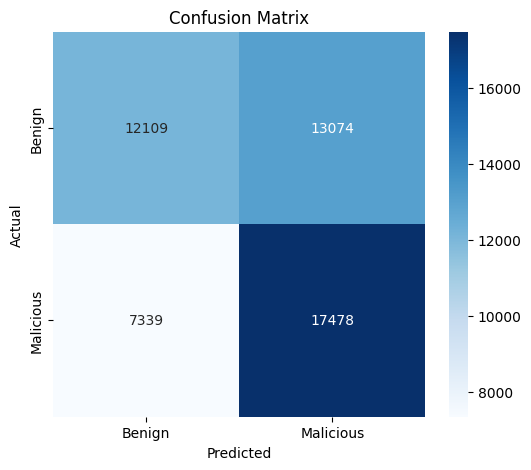

In [16]:
# Plot Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malicious'], yticklabels=['Benign', 'Malicious'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<Figure size 1000x800 with 0 Axes>

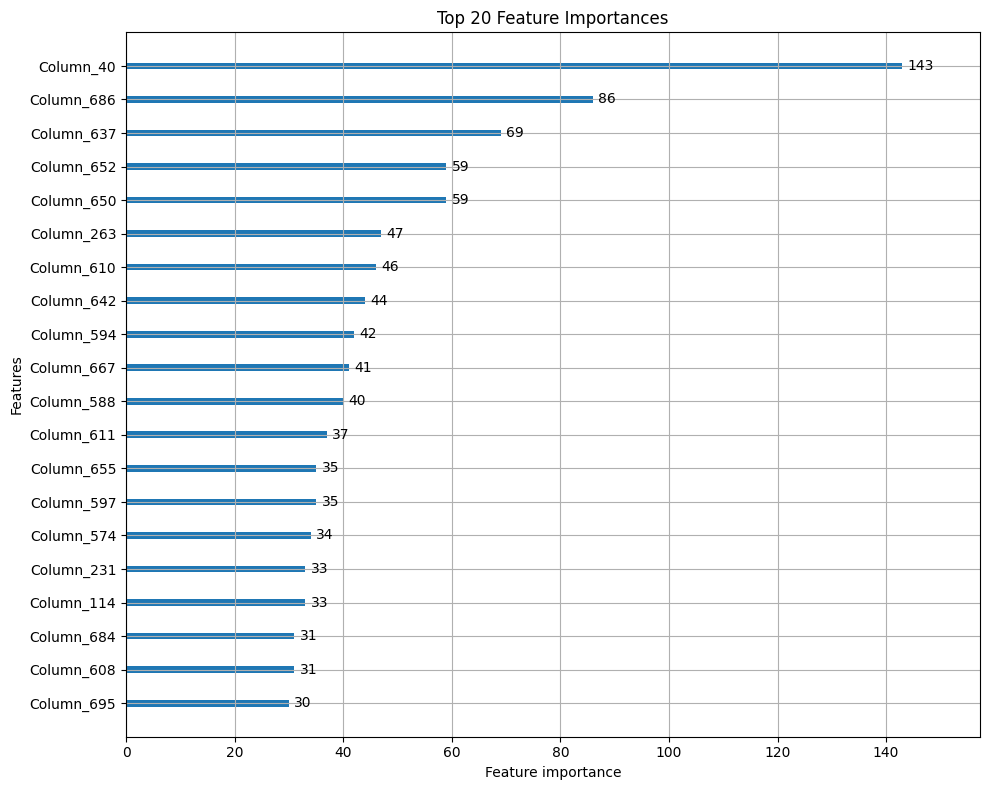

In [17]:
# Plot Feature Importance
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, max_num_features=20, title='Top 20 Feature Importances', figsize=(10, 8))
plt.tight_layout()
plt.show()

In [ ]:
# Save Model
model_path = os.path.join(r"Z:\ember2024_train_data\fraction_benchmark_models", "lightgbm_model_fraction_notebook.txt")
model.save_model(model_path)
print(f"Model successfully saved to: {model_path}")

Model successfully saved to: Z:\ember2024_train_data\lightgbm_model_fraction_notebook.txt
